In [15]:
# 统一论文图的风格和尺寸, 方便后续拼接
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm   # 修改 1：新增，用于手动加载 Arial.ttf


# =========================
# 修改 2：只需要改这里
# =========================
ARIAL_TTF_PATH = "/data/jychen/package/Arial/arial.ttf"   # 改成你的 arial.ttf 实际路径
USE_ARIAL_TTF = True                # True = 从 ttf 文件加载 Arial；False = 直接用系统字体名


_PUB_FONT_NAME = None


def load_pub_font():
    """
    手动加载 Arial.ttf，并返回字体在 matplotlib 中识别到的真实名称。
    这样可以避免系统装了 Arial 但 matplotlib 仍然找不到的问题。
    """
    global _PUB_FONT_NAME

    if _PUB_FONT_NAME is not None:
        return _PUB_FONT_NAME

    if USE_ARIAL_TTF:
        if not os.path.exists(ARIAL_TTF_PATH):
            raise FileNotFoundError(f"找不到 Arial 字体文件: {ARIAL_TTF_PATH}")

        fm.fontManager.addfont(ARIAL_TTF_PATH)
        _PUB_FONT_NAME = fm.FontProperties(fname=ARIAL_TTF_PATH).get_name()
    else:
        _PUB_FONT_NAME = "Arial"

    print(f"Using font: {_PUB_FONT_NAME}")
    return _PUB_FONT_NAME


def mm_to_inch(mm):
    return mm / 25.4


FIG_SIZE = {
    "single": 90,
    "double": 180,
}


FIG_PRESETS = {
    "single_small":  ("single", 60),
    "single_medium": ("single", 75),
    "single_large":  ("single", 90),
    "double_short":  ("double", 70),
    "double_medium": ("double", 100),
    "double_large":  ("double", 140),
}


_SHARED_FONT_SIZES = {
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
}


def set_pub_style():
    pub_font = load_pub_font()   # 修改 3：每次设置风格前，先确保 Arial.ttf 已经加载

    base = {
        # 修改 4：不再直接写死 "Arial"，而是使用 ttf 文件真实识别到的字体名
        "font.family": pub_font,
        "font.sans-serif": [pub_font, "Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],

        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # 稍粗一些的论文图风格
        "axes.linewidth": 1.5,
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.minor.width": 1.1,
        "ytick.minor.width": 1.1,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.8,
        "ytick.minor.size": 2.8,
        "xtick.direction": "in",
        "ytick.direction": "in",

        "lines.linewidth": 1.7,
        "patch.linewidth": 1.3,

        "legend.frameon": False,
        "legend.handlelength": 1.5,
        "legend.handletextpad": 0.4,

        "axes.unicode_minus": False,
        "axes.spines.top": True,
        "axes.spines.right": True,

        "savefig.dpi": 600,
        "figure.dpi": 120,
    }

    base.update(_SHARED_FONT_SIZES)
    mpl.rcParams.update(base)


def new_figure(mode="single", height_mm=65):
    set_pub_style()
    width_mm = FIG_SIZE[mode]
    fig, ax = plt.subplots(
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm))
    )
    return fig, ax


def new_subplots(nrows, ncols, preset="double_medium", **kwargs):
    set_pub_style()
    mode, height_mm = FIG_PRESETS[preset]
    width_mm = FIG_SIZE[mode]

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm)),
        **kwargs
    )
    return fig, axes


def savefig_pub(fig, filename, dpi=600, tight=False):
    if tight:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    else:
        fig.savefig(filename, dpi=dpi)


# 应用统一风格模板
set_pub_style()

Using font: Arial


In [16]:
# 后续分布分析的公共逻辑；绘图风格以 cell1 中的模板为准
import pickle
from pathlib import Path

import MDAnalysis as mda
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from tqdm import tqdm

FORCE_RECALCULATE = False
END_FRAME = None
STEP = 1
KEEP_LAST_N_CHAINS = 40

MEMBRANE_SEL = "name PO4"
PROTEIN_SEL = "protein"
EXPECTED_N_CHAINS = 50
RESIDUES_PER_CHAIN = 140

SEGMENTS_DEF = [
    {'name': 'N-Ter (1-60)', 'start': 1, 'end': 60},
    {'name': 'NAC (61-95)', 'start': 61, 'end': 95},
    {'name': 'C-Ter (96-140)', 'start': 96, 'end': 140},
]

PLOT_PRESET = 'single_large'
SEGMENT_COLORS = {
    'N-Ter (1-60)': 'blue',
    'NAC (61-95)': 'green',
    'C-Ter (96-140)': 'red',
}
SEGMENT_FALLBACK_COLORS = list(SEGMENT_COLORS.values())

DATA_ROOT = Path(
    '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/'
    'Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3'
)
TRAJECTORY_DIR = 'TR_Mdvwhole'
TOPOLOGY_FILE = 'pbc.tpr'
TRAJECTORY_FILE = 'deltT1000.xtc'

DATASET_GROUPS = {
    'alhx_0': ['alhx_0_plus1', 'alhx_0_plus2', 'alhx_0_plus3'],
    'alhx_700': ['alhx_700_WALL1', 'alhx_700_WALL2', 'alhx_700_WALL3'],
}


def make_datasets(names, root=DATA_ROOT):
    return [
        {
            'name': name,
            'topology': str(root / name / TRAJECTORY_DIR / TOPOLOGY_FILE),
            'trajectory': str(root / name / TRAJECTORY_DIR / TRAJECTORY_FILE),
        }
        for name in names
    ]


def analyze_distribution(
    topology_file,
    trajectory_file,
    *,
    start_frame=0,
    end_frame=END_FRAME,
    step=STEP,
    filter_chains=False,
    keep_last_n_chains=KEEP_LAST_N_CHAINS,
    membrane_sel=MEMBRANE_SEL,
    protein_sel=PROTEIN_SEL,
    expected_n_chains=EXPECTED_N_CHAINS,
    residues_per_chain=RESIDUES_PER_CHAIN,
    segments_def=SEGMENTS_DEF,
):
    print(f"正在加载拓扑: {topology_file} 和轨迹...")
    u = mda.Universe(topology_file, trajectory_file)

    trajectory_slice = u.trajectory[start_frame:end_frame:step]
    n_frames = len(trajectory_slice)
    print(f"分析范围设置: Frame {start_frame} -> {end_frame if end_frame else 'End'}, Step={step}")
    print(f"实际将处理帧数: {n_frames}")

    if n_frames == 0:
        raise ValueError("错误：选定的帧范围为空！请检查 start_frame 和 end_frame。")

    membrane = u.select_atoms(membrane_sel)
    protein_all = u.select_atoms(protein_sel)

    try:
        chains = protein_all.split('molecule')
        print(f"[方案A] 使用 split('molecule') 检测到 {len(chains)} 条链。")
    except Exception:
        chains = []
        print("[方案A] split('molecule') 失败。")

    if len(chains) != expected_n_chains:
        print(f"警告：检测到的链数量 ({len(chains)}) 与预期 ({expected_n_chains}) 不符！")
        print("[方案B] 启用“强制残基切分模式”...")
        all_residues = protein_all.residues
        total_res = len(all_residues)

        if total_res != expected_n_chains * residues_per_chain:
            raise ValueError(
                f"错误：选中的蛋白总残基数 ({total_res}) 不等于 "
                f"{expected_n_chains} * {residues_per_chain}。"
            )

        chains = []
        for i in range(expected_n_chains):
            start_idx = i * residues_per_chain
            end_idx = (i + 1) * residues_per_chain
            chains.append(all_residues[start_idx:end_idx])

        print(f"[方案B] 成功强制切分为 {len(chains)} 条链。")

    if filter_chains:
        original_count = len(chains)
        if original_count >= keep_last_n_chains:
            chains = chains[-keep_last_n_chains:]
            print(f"【筛选生效】原有 {original_count} 条，现只分析最后 {len(chains)} 条。")
        else:
            print(f"警告：原有链数量 ({original_count}) 少于请求保留的数量 ({keep_last_n_chains})，将分析所有链。")

    results = {seg['name']: [] for seg in segments_def}
    print("开始计算...")
    for _ in tqdm(trajectory_slice):
        z_mem_center = membrane.center_of_mass()[2]
        for chain in chains:
            ress = chain.residues if hasattr(chain, 'residues') else chain
            for seg_info in segments_def:
                fragment = ress[seg_info['start'] - 1:seg_info['end']]
                com_z = fragment.atoms.center_of_mass()[2]
                results[seg_info['name']].append(com_z - z_mem_center)

    return results


def save_plot_data(results, cache_file):
    with open(cache_file, 'wb') as f:
        pickle.dump(results, f)
    print(f"绘图数据已保存: {cache_file}")


def load_plot_data(cache_file):
    with open(cache_file, 'rb') as f:
        results = pickle.load(f)
    print(f"检测到已有绘图数据，直接读取: {cache_file}")
    return results


def get_combined_data(
    datasets,
    cache_file,
    *,
    force_recalculate=FORCE_RECALCULATE,
    **analysis_kwargs,
):
    cache_path = Path(cache_file)
    if cache_path.exists() and not force_recalculate:
        return load_plot_data(cache_path)

    segments_def = analysis_kwargs.get('segments_def', SEGMENTS_DEF)
    combined_data = {seg['name']: [] for seg in segments_def}
    for dataset in datasets:
        print(f"\n===== 累加轨迹数据: {dataset['name']} =====")
        data = analyze_distribution(
            dataset['topology'],
            dataset['trajectory'],
            **analysis_kwargs,
        )
        for key in combined_data:
            combined_data[key].extend(data[key])

    save_plot_data(combined_data, cache_path)
    return combined_data


def apply_nature_axes_style(ax):
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.minorticks_off()
    ax.tick_params(
        axis='both',
        which='major',
        direction=plt.rcParams['xtick.direction'],
        length=plt.rcParams['xtick.major.size'],
        width=plt.rcParams['xtick.major.width'],
        pad=4,
        bottom=True,
        left=True,
        top=False,
        right=False,
    )
    for spine in ax.spines.values():
        spine.set_linewidth(plt.rcParams['axes.linewidth'])
    ax.grid(False)


def plot_results(
    results,
    output_plot,
    *,
    plot_preset=PLOT_PRESET,
    segment_colors=SEGMENT_COLORS,
    fallback_colors=SEGMENT_FALLBACK_COLORS,
):
    if 'new_subplots' not in globals() or 'savefig_pub' not in globals():
        raise RuntimeError("请先运行第一个包含统一论文图风格的 cell。")

    print("正在绘图...")
    fig, ax = new_subplots(1, 1, preset=plot_preset)

    for i, (label, data) in enumerate(results.items()):
        if len(data) == 0:
            print(f"警告: {label} 没有数据！")
            continue
        color = segment_colors.get(label, fallback_colors[i % len(fallback_colors)])
        sns.kdeplot(
            data,
            label=label,
            fill=True,
            alpha=0.25,
            linewidth=plt.rcParams['lines.linewidth'],
            color=color,
            ax=ax,
        )

    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.1, alpha=0.9)
    ax.set_xlabel('Δz from membrane center (Å)')
    ax.set_ylabel('Density')
    apply_nature_axes_style(ax)
    ax.legend(loc='upper right', frameon=False, handlelength=1.6, borderpad=0.2)

    fig.tight_layout(pad=0.5)
    savefig_pub(fig, output_plot, tight=True)
    print(f"图片保存至: {output_plot}")
    plt.show()


def run_distribution_analysis(
    *,
    datasets,
    output_plot,
    cache_file,
    force_recalculate=FORCE_RECALCULATE,
    start_frame=0,
    end_frame=END_FRAME,
    step=STEP,
    filter_chains=False,
    keep_last_n_chains=KEEP_LAST_N_CHAINS,
    membrane_sel=MEMBRANE_SEL,
    protein_sel=PROTEIN_SEL,
    expected_n_chains=EXPECTED_N_CHAINS,
    residues_per_chain=RESIDUES_PER_CHAIN,
    segments_def=SEGMENTS_DEF,
    plot_preset=PLOT_PRESET,
    segment_colors=SEGMENT_COLORS,
    fallback_colors=SEGMENT_FALLBACK_COLORS,
):
    combined_data = get_combined_data(
        datasets,
        cache_file,
        force_recalculate=force_recalculate,
        start_frame=start_frame,
        end_frame=end_frame,
        step=step,
        filter_chains=filter_chains,
        keep_last_n_chains=keep_last_n_chains,
        membrane_sel=membrane_sel,
        protein_sel=protein_sel,
        expected_n_chains=expected_n_chains,
        residues_per_chain=residues_per_chain,
        segments_def=segments_def,
    )
    plot_results(
        combined_data,
        output_plot,
        plot_preset=plot_preset,
        segment_colors=segment_colors,
        fallback_colors=fallback_colors,
    )
    return combined_data


In [17]:
# alhx_0
combined_data_alhx_0 = get_combined_data(
    datasets=make_datasets(DATASET_GROUPS['alhx_0']),
    cache_file='protein_distribution_NTer_combined_alhx_0.pkl',
    start_frame=0,
    filter_chains=False,
)
combined_data = combined_data_alhx_0


检测到已有绘图数据，直接读取: protein_distribution_NTer_combined_alhx_0.pkl


In [18]:
# alhx_700：全部链
combined_data_alhx_700 = get_combined_data(
    datasets=make_datasets(DATASET_GROUPS['alhx_700']),
    cache_file='protein_distribution_NTer_combined_alhx_700.pkl',
    start_frame=10000,
    filter_chains=False,
)
combined_data = combined_data_alhx_700


检测到已有绘图数据，直接读取: protein_distribution_NTer_combined_alhx_700.pkl


In [19]:
# alhx_700：只分析最后 40 条链
combined_data_alhx_700_last40 = get_combined_data(
    datasets=make_datasets(DATASET_GROUPS['alhx_700']),
    cache_file='protein_distribution_NTer_last40_combined_alhx_700.pkl',
    start_frame=10000,
    filter_chains=True,
)
combined_data = combined_data_alhx_700_last40


检测到已有绘图数据，直接读取: protein_distribution_NTer_last40_combined_alhx_700.pkl


Main-text dz summary from replicate medians (mean ± SD, nm):
$\text{IDP}_{50}$-Mem
  N-ter: 6.76 ± 0.24; reps=[6.52, 6.77, 7.00], n=1,499,566
  NAC: 8.56 ± 0.27; reps=[8.83, 8.29, 8.55], n=1,499,855
  C-ter: 8.47 ± 0.27; reps=[8.62, 8.15, 8.63], n=1,499,159
$\text{Hel}_{10}\text{IDP}_{40}$-Mem: IDP chains
  N-ter: 5.84 ± 0.23; reps=[5.97, 5.97, 5.58], n=1,151,167
  NAC: 7.48 ± 0.48; reps=[6.93, 7.76, 7.76], n=1,151,566
  C-ter: 7.51 ± 0.48; reps=[6.96, 7.77, 7.79], n=1,151,133

Segment displacement relative to N-ter (mean of replicate medians, nm):
$\text{IDP}_{50}$-Mem
  NAC - N-ter: 1.79 nm
  C-ter - N-ter: 1.70 nm
$\text{Hel}_{10}\text{IDP}_{40}$-Mem: IDP chains
  NAC - N-ter: 1.64 nm
  C-ter - N-ter: 1.67 nm
图片保存至: protein_segment_dz_main_summary.png


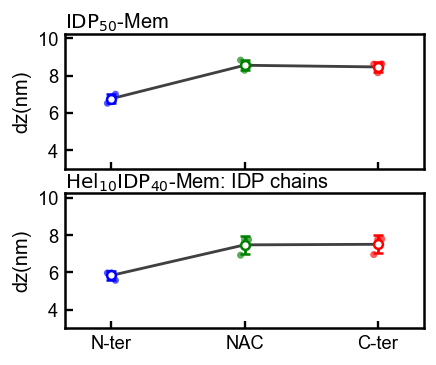

In [23]:
# 正文主图：上下两个 panel 分别展示两组 IDP chains 的 segment dz 分层
import numpy as np

ANGSTROM_TO_NM = 0.1
DZ_RANGE_NM = (0, 20)
DZ_AXIS_YMIN_NM = 3
N_REPLICATES = 3
MAIN_OUTPUT_PLOT = 'protein_segment_dz_main_summary.png'

MAIN_DZ_GROUPS = [
    (r'$\text{IDP}_{50}$-Mem', combined_data_alhx_0),
    (r'$\text{Hel}_{10}\text{IDP}_{40}$-Mem: IDP chains', combined_data_alhx_700_last40),
]
SEGMENT_ORDER = [seg['name'] for seg in SEGMENTS_DEF]
SEGMENT_SHORT_LABELS = {
    'N-Ter (1-60)': 'N-ter',
    'NAC (61-95)': 'NAC',
    'C-Ter (96-140)': 'C-ter',
}
SEGMENT_PLOT_COLORS = [
    SEGMENT_COLORS.get(segment, SEGMENT_FALLBACK_COLORS[i % len(SEGMENT_FALLBACK_COLORS)])
    for i, segment in enumerate(SEGMENT_ORDER)
]


def _clip_to_plot_range_nm(values_angstrom):
    values_nm = np.asarray(values_angstrom, dtype=float) * ANGSTROM_TO_NM
    values_nm = values_nm[np.isfinite(values_nm)]
    return values_nm[(values_nm >= DZ_RANGE_NM[0]) & (values_nm <= DZ_RANGE_NM[1])]


def segment_replicate_summary_nm(panel_data, segment_order=SEGMENT_ORDER, n_replicates=N_REPLICATES):
    rep_medians = np.full((len(segment_order), n_replicates), np.nan)
    rep_counts = np.zeros((len(segment_order), n_replicates), dtype=int)

    for seg_idx, segment in enumerate(segment_order):
        values = np.asarray(panel_data[segment], dtype=float)
        if values.size % n_replicates != 0:
            raise ValueError(f'{segment} 的数据长度 {values.size} 不能被 {n_replicates} 个重复整除。')

        for rep_idx, rep_values in enumerate(np.split(values, n_replicates)):
            rep_values_nm = _clip_to_plot_range_nm(rep_values)
            rep_counts[seg_idx, rep_idx] = rep_values_nm.size
            if rep_values_nm.size > 0:
                rep_medians[seg_idx, rep_idx] = np.median(rep_values_nm)

    return {
        'rep_medians': rep_medians,
        'mean': np.nanmean(rep_medians, axis=1),
        'sd': np.nanstd(rep_medians, axis=1, ddof=1),
        'counts': rep_counts,
    }


main_summaries = [
    (label, segment_replicate_summary_nm(data))
    for label, data in MAIN_DZ_GROUPS
]

print('Main-text dz summary from replicate medians (mean ± SD, nm):')
for label, summary in main_summaries:
    print(label)
    for seg_idx, segment in enumerate(SEGMENT_ORDER):
        short = SEGMENT_SHORT_LABELS.get(segment, segment)
        reps = ', '.join(f'{value:.2f}' for value in summary['rep_medians'][seg_idx])
        total_n = int(summary['counts'][seg_idx].sum())
        print(f"  {short}: {summary['mean'][seg_idx]:.2f} ± {summary['sd'][seg_idx]:.2f}; reps=[{reps}], n={total_n:,}")

print('\nSegment displacement relative to N-ter (mean of replicate medians, nm):')
for label, summary in main_summaries:
    rel = summary['mean'] - summary['mean'][0]
    print(label)
    for segment, value in zip(SEGMENT_ORDER[1:], rel[1:]):
        short = SEGMENT_SHORT_LABELS.get(segment, segment)
        print(f'  {short} - N-ter: {value:.2f} nm')

MAIN_DZ_PANELS = [
    (main_summaries[0][0], main_summaries[0][1]),
    (main_summaries[1][0], main_summaries[1][1]),
]


def plot_single_group_panel(ax, label, summary, *, show_xticklabels=True):
    x = np.arange(len(SEGMENT_ORDER), dtype=float)
    replicate_offsets = np.linspace(-0.03, 0.03, N_REPLICATES)
    panel_y = []
    means = summary['mean']
    sd = summary['sd']
    valid_mean = np.isfinite(means)

    ax.plot(
        x[valid_mean],
        means[valid_mean],
        color='0.25',
        linewidth=plt.rcParams['lines.linewidth'],
        zorder=1,
    )

    for seg_idx, (segment, color) in enumerate(zip(SEGMENT_ORDER, SEGMENT_PLOT_COLORS)):
        rep_values = summary['rep_medians'][seg_idx]
        valid_rep = np.isfinite(rep_values)
        panel_y.extend(rep_values[valid_rep].tolist())
        ax.scatter(
            x[seg_idx] + replicate_offsets[valid_rep],
            rep_values[valid_rep],
            s=18,
            color=color,
            alpha=0.65,
            edgecolors='none',
            zorder=2,
        )
        if np.isfinite(means[seg_idx]):
            panel_y.append(means[seg_idx] + sd[seg_idx])
            ax.errorbar(
                x[seg_idx],
                means[seg_idx],
                yerr=sd[seg_idx],
                fmt='o',
                linestyle='none',
                color=color,
                markerfacecolor='white',
                markeredgewidth=1.5,
                markersize=5.3,
                linewidth=plt.rcParams['lines.linewidth'],
                elinewidth=plt.rcParams['lines.linewidth'],
                capsize=3,
                zorder=3,
            )

    ax.set_title(label, loc='left', pad=1)
    ax.set_ylabel('dz(nm)')
    ax.set_xlabel('')
    ax.set_xlim(-0.35, len(SEGMENT_ORDER) - 0.65)
    apply_nature_axes_style(ax)
    ax.set_xticks(x)
    ax.set_xticklabels([SEGMENT_SHORT_LABELS.get(segment, segment) for segment in SEGMENT_ORDER])
    if not show_xticklabels:
        ax.tick_params(labelbottom=False)
    return panel_y


fig, axes = new_subplots(len(MAIN_DZ_PANELS), 1, preset='single_medium', sharex=True, sharey=True)
try:
    axes = axes.ravel().tolist()
except AttributeError:
    axes = [axes]

all_y = []
for panel_idx, (ax, (panel_label, panel_summary)) in enumerate(zip(axes, MAIN_DZ_PANELS)):
    all_y.extend(
        plot_single_group_panel(
            ax,
            panel_label,
            panel_summary,
            show_xticklabels=(panel_idx == len(axes) - 1),
        )
    )

if all_y:
    upper_ylim = max(max(all_y) * 1.16, DZ_AXIS_YMIN_NM + 1.0)
    for ax in axes:
        ax.set_ylim(DZ_AXIS_YMIN_NM, min(DZ_RANGE_NM[1], upper_ylim))

fig.subplots_adjust(hspace=0.13)
fig.tight_layout(pad=0.35, h_pad=0.12)
savefig_pub(fig, MAIN_OUTPUT_PLOT, tight=True)
print(f"图片保存至: {MAIN_OUTPUT_PLOT}")
plt.show()


正在绘制纵向比较图...
图片保存至: protein_distribution_NTer_column_comparison.png


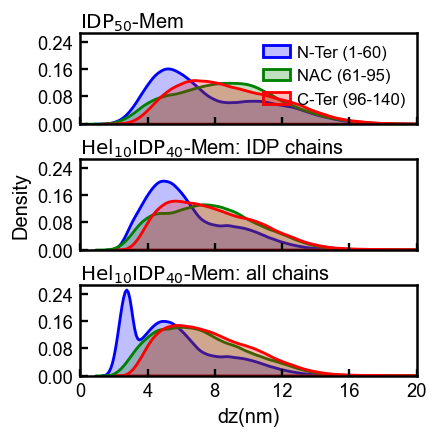

In [25]:
# 三个分布图纵向排列，便于在同一 x 轴上比较
import numpy as np

comparison_panels = [
    (r'$\text{IDP}_{50}$-Mem', combined_data_alhx_0),
    (r'$\text{Hel}_{10}\text{IDP}_{40}$-Mem: IDP chains', combined_data_alhx_700_last40),
    (r'$\text{Hel}_{10}\text{IDP}_{40}$-Mem: all chains', combined_data_alhx_700),
]
output_plot = 'protein_distribution_NTer_column_comparison.png'
ANGSTROM_TO_NM = 0.1
DZ_RANGE_NM = (0, 20)

print("正在绘制纵向比较图...")
fig, axes = new_subplots(len(comparison_panels), 1, preset=PLOT_PRESET, sharex=True)
try:
    axes = axes.ravel().tolist()
except AttributeError:
    axes = [axes]

for row, (ax, (panel_title, panel_data)) in enumerate(zip(axes, comparison_panels)):
    for i, (label, data) in enumerate(panel_data.items()):
        if len(data) == 0:
            print(f"警告: {panel_title} / {label} 没有数据！")
            continue

        data_nm = np.asarray(data, dtype=float) * ANGSTROM_TO_NM
        data_nm = data_nm[(data_nm >= DZ_RANGE_NM[0]) & (data_nm <= DZ_RANGE_NM[1])]
        if data_nm.size == 0:
            print(f"警告: {panel_title} / {label} 在 {DZ_RANGE_NM[0]}-{DZ_RANGE_NM[1]} nm 范围内没有数据！")
            continue

        color = SEGMENT_COLORS.get(label, SEGMENT_FALLBACK_COLORS[i % len(SEGMENT_FALLBACK_COLORS)])
        sns.kdeplot(
            data_nm,
            label=label,
            fill=True,
            alpha=0.25,
            linewidth=plt.rcParams['lines.linewidth'],
            color=color,
            ax=ax,
            clip=DZ_RANGE_NM,
            cut=0,
        )

    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.1, alpha=0.9)
    ax.set_title(panel_title, loc='left', pad=1)
    ax.set_xlabel('')
    ax.set_ylabel('Density' if row == 1 else '')
    ax.set_xlim(*DZ_RANGE_NM)
    apply_nature_axes_style(ax)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    axes[0].legend(handles, labels, loc='upper right', frameon=False, handlelength=1.6, borderpad=0.2)
for ax in axes[1:]:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

shared_ymax = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(0, shared_ymax)
    ax.set_xlim(*DZ_RANGE_NM)
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)
axes[-1].set_xlabel('dz(nm)')

fig.subplots_adjust(hspace=0.16)
fig.tight_layout(pad=0.28, h_pad=0.12)
savefig_pub(fig, output_plot, tight=True)
print(f"图片保存至: {output_plot}")
plt.show()
